# Modelo Random Forest

In [37]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler  
from sklearn.ensemble import RandomForestClassifier   
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay


In [38]:
# 1. Cargar los datos procesados
X_train_sel = pd.read_csv("clean_dataset_train.csv")
X_test_sel = pd.read_csv("clean_dataset_test.csv")

In [39]:
# 3. Separar variables predictoras (X) y variable objetivo (y)
y_train = X_train_sel["Outcome"]
X_train = X_train_sel.drop("Outcome", axis=1)

y_test = X_test_sel["Outcome"]
X_test = X_test_sel.drop("Outcome", axis=1)


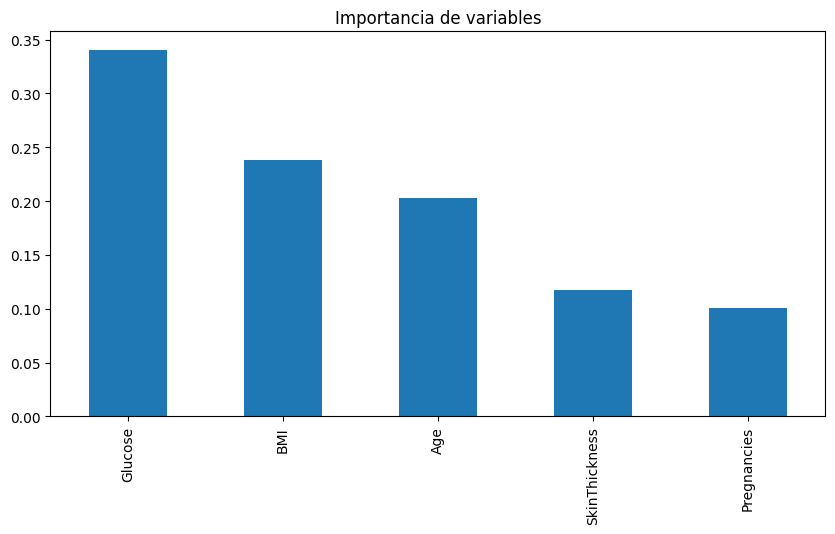

In [ ]:
# importacia de las variables 
importances = rf.feature_importances_
features = X_train.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10,5), title="Importancia de variables")
plt.show()

In [40]:
# 4. Crear y entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# 5. Predicciones
y_pred = rf.predict(X_test)

C:\Users\7sean\AppData\Local\Temp\ipykernel_10868\2379855260.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")


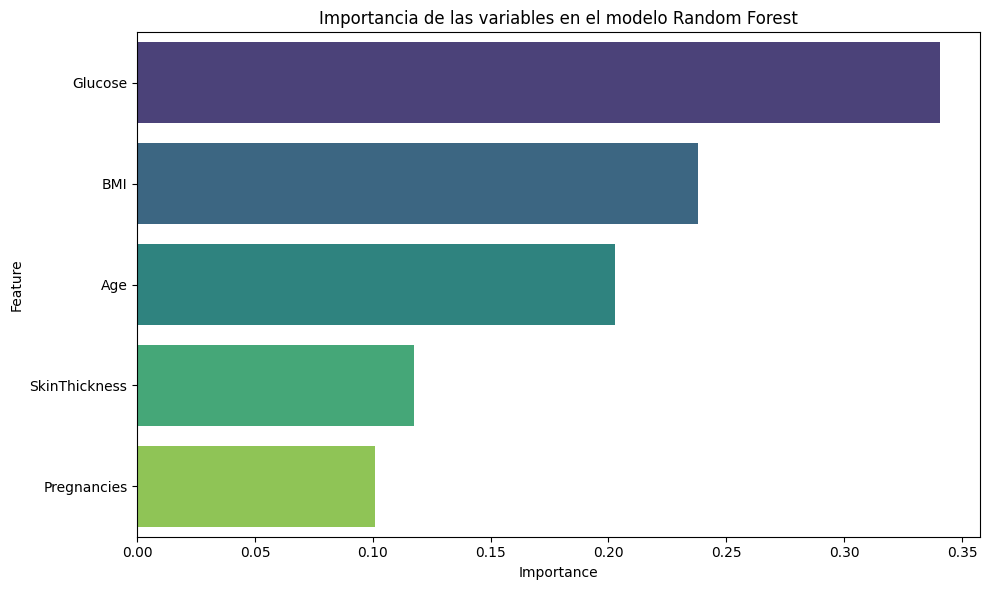

In [42]:
#  Importancia de las variables 
importances = rf.feature_importances_
features = X_train.columns
feature_df = pd.DataFrame({"Feature": features, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")
plt.title("Importancia de las variables en el modelo Random Forest")
plt.tight_layout()
plt.show()

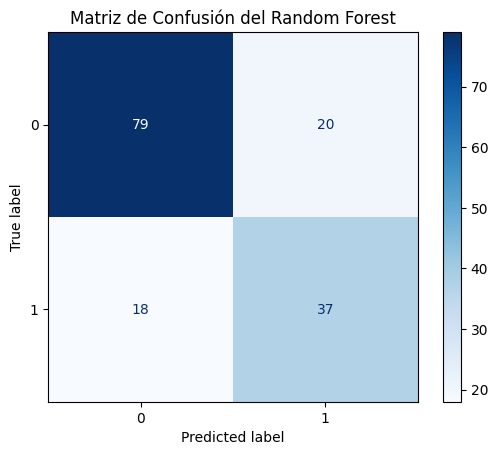

In [43]:
# Matriz de confusión (heatmap)
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap="Blues")
plt.title("Matriz de Confusión del Random Forest")
plt.show()

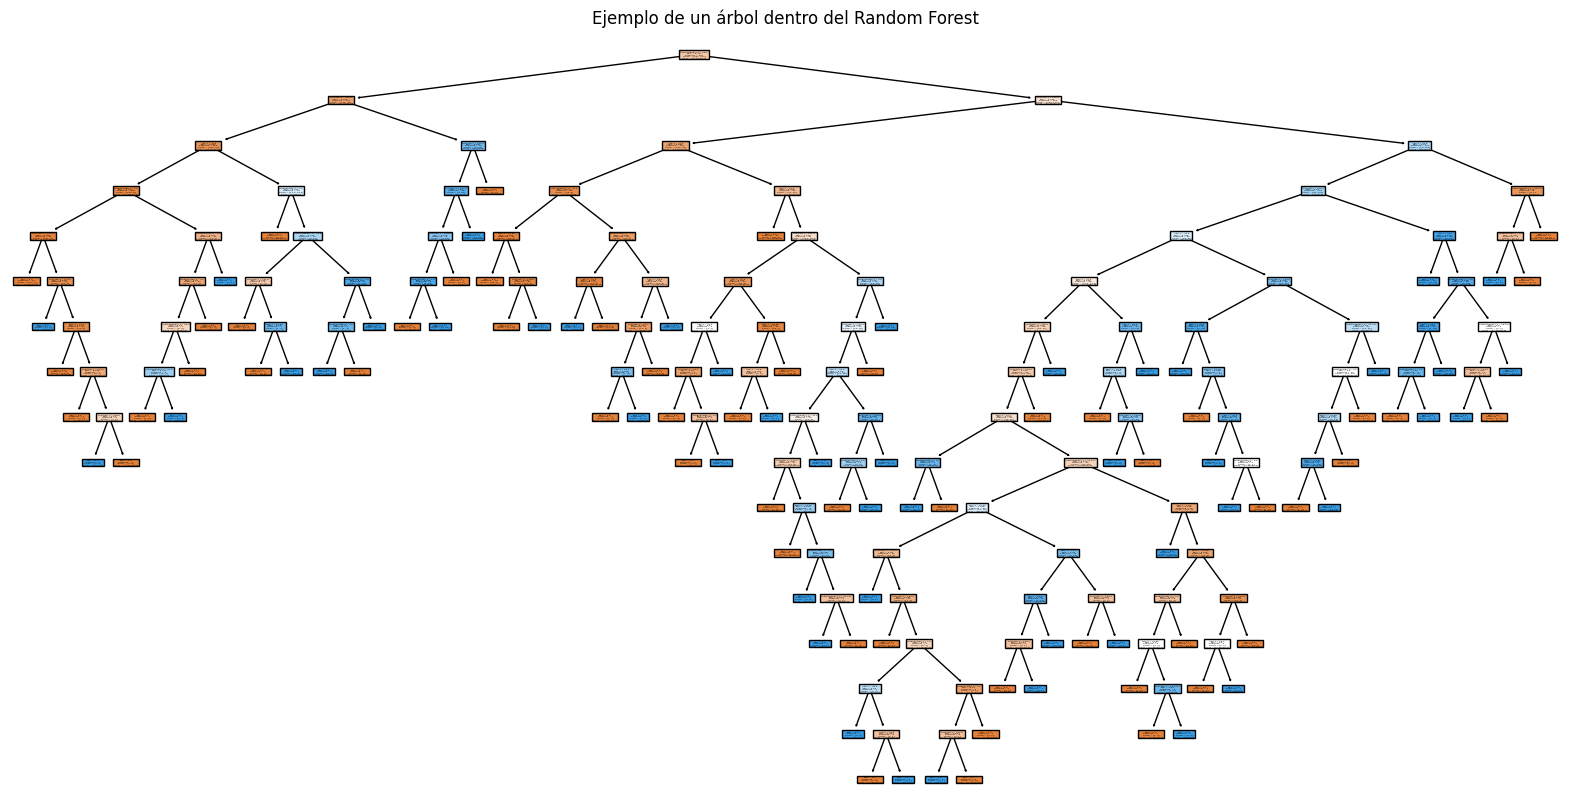

In [44]:
#  Visualizar un árbol individual del bosque
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=X_train.columns, class_names=["No Diabetes", "Diabetes"], filled=True)
plt.title("Ejemplo de un árbol dentro del Random Forest")
plt.show()

In [45]:
# 6. Evaluaciones
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy, pd.DataFrame(report).T, pd.DataFrame(conf_matrix)

(0.7532467532467533,
               precision    recall  f1-score     support
 0              0.814433  0.797980  0.806122   99.000000
 1              0.649123  0.672727  0.660714   55.000000
 accuracy       0.753247  0.753247  0.753247    0.753247
 macro avg      0.731778  0.735354  0.733418  154.000000
 weighted avg   0.755394  0.753247  0.754191  154.000000,
     0   1
 0  79  20
 1  18  37)

1. Desempeño general del modelo:

El modelo logró una exactitud del 75.3%, lo cual es un resultado razonable para un problema de clasificación médica. Sin embargo, no es lo suficientemente alto como para considerarse confiable en entornos críticos sin validación adicional.

2. Predicción de pacientes con diabetes (clase 1):

- El modelo detecta correctamente un 67% de los casos de diabetes (recall), lo cual es aceptable pero podría ser mejor.

- Tiene una precisión del 65%: es decir, de cada 100 predicciones positivas, solo 65 eran realmente pacientes con diabetes.

- Se producen 18 falsos negativos, lo que significa que algunos pacientes con diabetes no fueron detectados, lo cual es preocupante en salud pública.

3. Predicción de pacientes sin diabetes (clase 0):

El rendimiento es mucho mejor: precisión y recall ambos cerca del 80%.

Esto indica que el modelo es más fiable al decir que una persona no tiene diabetes que al decir que sí la tiene.

4. Balance del modelo: 

El modelo está ligeramente desbalanceado: funciona mejor para la clase mayoritaria (no diabéticos).

Conclusion final 

El modelo Random Forest alcanzó una precisión general del 75.3% en la clasificación de pacientes con y sin diabetes. Muestra un buen desempeño en la identificación de pacientes no diabéticos (81% de precisión), pero es menos preciso en la detección de casos positivos (65% de precisión, 67% de recall). Esto implica que, aunque útil como herramienta de apoyo, el modelo puede pasar por alto algunos casos reales de diabetes


